# 09 ONNX Export + Parity Check v1

이 노트북의 목적은 05에서 학습한 `best.pth`를 ONNX로 export하고, **로컬 PyTorch 결과와 ONNX Runtime 결과가 같은 인터페이스를 유지하는지** 확인하는 것이다.

여기서 새 조향 정책을 정하지 않는다.  
09는 07 decoder contract와 08 steering profile 후보가 **ONNX 배포 경로에서도 같은 결과를 내는지** 확인하는 검증 노트북이다.


## 검증 범위

아래 세 층을 순서대로 확인한다.

1. **Raw model parity**  
   같은 BGR `[0,1]` tensor를 넣었을 때 PyTorch `best.pth`와 ONNX가 같은 raw output `(192, 78)`을 내는가?

2. **Decode parity**  
   07에서 확정한 `official_overlap_python`, `conf_threshold=0.35`, `nms_thres=70`을 둘 다에 적용했을 때 lane 좌표가 같은가?

3. **Steering parity**  
   08에서 만든 steering profile 후보를 같은 lane 좌표에 적용했을 때 `steer_norm`이 같은가?

주의: 08 steering profile 자체는 아직 실주행에서 튜닝할 수 있다.  
09의 관심사는 **같은 profile을 썼을 때 PyTorch 경로와 ONNX 경로가 같은 결과를 내는지**다.


In [1]:
from pathlib import Path
import os
import sys
import json
import time
import math
from collections import defaultdict

import numpy as np
import pandas as pd
import torch

try:
    import cv2
except Exception as e:
    raise ImportError("This notebook needs opencv-python / cv2 in the local runtime.") from e

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

from IPython.display import display, Image, Markdown

EXP_ROOT = Path(r"~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild")
SHARED_LANE_ROOT = Path(r"~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\dataset\lane")
DATASET_DIR = SHARED_LANE_ROOT / "map_culane_localfit_train_field1_field2_v1"
RAW_ROOT = SHARED_LANE_ROOT / "raw"
HOLDOUT_ROOT = SHARED_LANE_ROOT / "holdout"

RUN_DIR = EXP_ROOT / "colab_outputs" / "MapLane_LocalFit_Field12_v1_full" / "20260509_102232_lr_1e-04_b_8"
CODE_DIR = RUN_DIR / "code"
CONFIG_PATH = EXP_ROOT / "colab_outputs" / "meta" / "MapLane_LocalFit_Field12_v1_ResNet18_full.py"
BEST_CKPT = RUN_DIR / "ckpt" / "best.pth"

DECODE_CONTRACT_PATH = EXP_ROOT / "review_outputs" / "07_decode_contract_v1" / "decode_contract_v1.json"
DRIVE_CONTRACT_PATH = EXP_ROOT / "review_outputs" / "08_driving_postprocess_contract_v1" / "inside_memory_driving_postprocess_contract_candidate.json"

REVIEW_ROOT = EXP_ROOT / "review_outputs" / "09_onnx_export_parity_v1"
MODEL_DIR = REVIEW_ROOT / "models"
TABLE_DIR = REVIEW_ROOT / "tables"
OVERLAY_DIR = REVIEW_ROOT / "overlays"
for d in [REVIEW_ROOT, MODEL_DIR, TABLE_DIR, OVERLAY_DIR]:
    d.mkdir(parents=True, exist_ok=True)

ONNX_PATH = MODEL_DIR / "MapLane_LocalFit_Field12_v1_best_opset17_static_b1.onnx"
PARITY_REPORT_PATH = REVIEW_ROOT / "onnx_parity_report_v1.json"

# Run All을 너무 무겁게 만들지 않기 위한 기본값. 필요하면 늘려서 다시 측정한다.
MAX_VAL_FRAMES = 12
MAX_FIELD3_FRAMES = 80
MAX_HOLDOUT_FRAMES = 24
OVERLAY_SAMPLE_FRAMES = 12

OPSET_VERSION = 17
RAW_MAX_ABS_TOL = 5e-3
RAW_MEAN_ABS_TOL = 5e-4
LANE_MEAN_DIST_TOL_PX = 2.0
STEER_TOL = 2e-3

print("EXP_ROOT:", EXP_ROOT)
print("REVIEW_ROOT:", REVIEW_ROOT)


EXP_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild
REVIEW_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\09_onnx_export_parity_v1


In [2]:
required_paths = {
    "CODE_DIR": CODE_DIR,
    "CONFIG_PATH": CONFIG_PATH,
    "BEST_CKPT": BEST_CKPT,
    "DATASET_DIR": DATASET_DIR,
    "VAL_LIST": DATASET_DIR / "list" / "val.txt",
    "RAW_FIELD3": RAW_ROOT / "field3",
    "HOLDOUT_ROOT": HOLDOUT_ROOT,
    "DECODE_CONTRACT": DECODE_CONTRACT_PATH,
    "DRIVE_CONTRACT": DRIVE_CONTRACT_PATH,
}
for name, path in required_paths.items():
    print(f"{name:16s}", path, "exists=", path.exists())
    assert path.exists(), f"missing required path: {name} -> {path}"

decode_contract = json.loads(DECODE_CONTRACT_PATH.read_text(encoding="utf-8"))
drive_contract = json.loads(DRIVE_CONTRACT_PATH.read_text(encoding="utf-8"))

print("decoder:", decode_contract["decoder_contract"]["name"])
print("decoder conf/nms:", decode_contract["decoder_contract"]["conf_threshold"], decode_contract["decoder_contract"]["nms_thres"])
print("driving profile:", drive_contract["driving_contract"]["name"])


CODE_DIR         ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\colab_outputs\MapLane_LocalFit_Field12_v1_full\20260509_102232_lr_1e-04_b_8\code exists= True
CONFIG_PATH      ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\colab_outputs\meta\MapLane_LocalFit_Field12_v1_ResNet18_full.py exists= True
BEST_CKPT        ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\colab_outputs\MapLane_LocalFit_Field12_v1_full\20260509_102232_lr_1e-04_b_8\ckpt\best.pth exists= True
DATASET_DIR      ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\dataset\lane\map_culane_localfit_train_field1_field2_v1 exists= True
VAL_LIST         ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\dataset\lane\map_culane_localfit_train_field1_field2_v1\list\val.

## Windows long path helper

데이터셋 경로가 길어서 Windows 기본 path 처리로 실패할 수 있다.  
이미지 입출력은 `\\?\` prefix와 `np.fromfile` 기반으로 처리한다.


In [3]:
def long_path(path):
    p = Path(path)
    s = str(p.resolve())
    if sys.platform.startswith("win") and not s.startswith("\\\\?\\"):
        return "\\\\?\\" + s
    return s


def exists_path(path):
    return os.path.exists(long_path(path))


def read_text(path, encoding="utf-8"):
    with open(long_path(path), "r", encoding=encoding) as f:
        return f.read()


def write_text(path, text, encoding="utf-8"):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(long_path(path), "w", encoding=encoding) as f:
        f.write(text)


def imread_bgr(path):
    data = np.fromfile(long_path(path), dtype=np.uint8)
    img = cv2.imdecode(data, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"cv2.imdecode failed: {path}")
    return img


def imwrite_bgr(path, image):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    ok, buf = cv2.imencode(path.suffix or ".jpg", image)
    if not ok:
        raise RuntimeError(f"cv2.imencode failed: {path}")
    buf.tofile(long_path(path))
    return path


def load_py_config_without_temp(config_path):
    """Load a CLRKDNet .py config without Config.fromfile's temp-file copy path.

    The official Config.fromfile copies the config to a temporary Python file
    before importing it. On Windows notebooks that temporary write can fail
    with PermissionError, so we execute the config text directly and then wrap
    it with the official Config object.
    """
    from clrkd.utils.config import Config

    config_path = Path(config_path)
    text = read_text(config_path)
    namespace = {}
    exec(compile(text, str(config_path), "exec"), namespace)
    cfg_dict = {k: v for k, v in namespace.items() if not k.startswith("__")}
    return Config(cfg_dict, cfg_text=text, filename=str(config_path))


## ONNX dependency check

`torch.onnx.export`는 PyTorch에 들어있지만, export 파일 검증과 실행에는 `onnx`, `onnxruntime`이 필요하다.  
없으면 아래 셀이 명확한 설치 명령을 출력하고 멈춘다.


In [4]:
missing = []
try:
    import onnx
except Exception:
    missing.append("onnx")
try:
    import onnxruntime as ort
except Exception:
    missing.append("onnxruntime")

if missing:
    print("missing modules:", missing)
    print("Install in this notebook/kernel environment:")
    print("    %pip install onnx onnxruntime")
    raise ImportError(f"missing ONNX dependencies: {missing}")

print("onnx:", onnx.__version__)
print("onnxruntime:", ort.__version__)
print("available ORT providers:", ort.get_available_providers())


onnx: 1.21.0
onnxruntime: 1.23.2
available ORT providers: ['AzureExecutionProvider', 'CPUExecutionProvider']


## 모델 로딩

Parity는 CPU 기준으로 확인한다.  
Pi 배포도 기본적으로 batch=1 runtime이므로, ONNX는 static batch 1로 export한다.


In [5]:
# 같은 kernel에서 이전 notebook의 clrkd import가 남아있을 수 있으니 비운다.
for module_name in list(sys.modules.keys()):
    if module_name == "clrkd" or module_name.startswith("clrkd."):
        del sys.modules[module_name]

sys.path.insert(0, str(CODE_DIR))

from clrkd.utils.config import Config
import clrkd.models
from clrkd.models.registry import build_net

cfg = load_py_config_without_temp(CONFIG_PATH)
cfg.test_parameters.conf_threshold = float(decode_contract["decoder_contract"]["conf_threshold"])
cfg.test_parameters.nms_thres = float(decode_contract["decoder_contract"]["nms_thres"])
cfg.test_parameters.nms_topk = int(decode_contract["decoder_contract"]["nms_topk"])

device = torch.device("cpu")
model = build_net(cfg).to(device)
ckpt = torch.load(long_path(BEST_CKPT), map_location=device)
state = ckpt["net"] if isinstance(ckpt, dict) and "net" in ckpt else ckpt
state = {k.replace("module.", "", 1): v for k, v in state.items()}
missing, unexpected = model.load_state_dict(state, strict=False)
print("missing:", len(missing), missing[:5])
print("unexpected:", len(unexpected), unexpected[:5])
assert len(missing) == 0 and len(unexpected) == 0
model.eval()
head = model.heads

print("geometry:", cfg.ori_img_w, cfg.ori_img_h, "cut_height=", cfg.cut_height, "input=", cfg.img_w, cfg.img_h)
print("raw shape expectation:", (cfg.heads.num_priors, 2 + 4 + cfg.num_points))


missing: 0 []
unexpected: 0 []
geometry: 1296 972 cut_height= 445 input= 800 320
raw shape expectation: (192, 78)


## Preprocess contract

09는 07/08에서 실제로 사용한 runtime preprocess를 그대로 따른다.

```text
raw BGR 1296x972
→ y = cut_height 아래쪽만 crop
→ 800x320 resize
→ float32 / 255
→ CHW tensor
```

이 preprocess가 Pi runtime에도 그대로 들어가야 한다.


In [6]:
def preprocess_bgr_for_model(bgr, cfg):
    crop = bgr[int(cfg.cut_height):, :, :]
    resized = cv2.resize(crop, (int(cfg.img_w), int(cfg.img_h)), interpolation=cv2.INTER_LINEAR)
    tensor = resized.astype(np.float32).transpose(2, 0, 1)[None, ...] / 255.0
    return tensor


val_lines = [line.strip() for line in read_text(DATASET_DIR / "list" / "val.txt").splitlines() if line.strip()]
probe_path = DATASET_DIR / val_lines[0].lstrip("/")
probe_bgr = imread_bgr(probe_path)
probe_tensor_np = preprocess_bgr_for_model(probe_bgr, cfg)
print("probe:", probe_path.name, "raw image:", probe_bgr.shape)
print("tensor:", probe_tensor_np.shape, probe_tensor_np.dtype, float(probe_tensor_np.min()), float(probe_tensor_np.max()))
assert probe_tensor_np.shape == (1, 3, cfg.img_h, cfg.img_w)
assert 0.0 <= float(probe_tensor_np.min()) <= 1.0
assert 0.0 <= float(probe_tensor_np.max()) <= 1.0


probe: c32b806f_20260430_160203_lane_none_intersection_none_cent.jpg raw image: (972, 1296, 3)
tensor: (1, 3, 320, 800) float32 0.05098039284348488 0.9372549057006836


## PyTorch wrapper와 ONNX export

CLRKDNet `Detector.forward()`는 원래 `{'img': tensor}` dict를 받는다.  
ONNX export에서는 dict 대신 image tensor 하나를 직접 받도록 wrapper를 둔다.


In [7]:
class ExportWrapper(torch.nn.Module):
    def __init__(self, detector):
        super().__init__()
        self.detector = detector

    def forward(self, img):
        return self.detector({"img": img})


export_model = ExportWrapper(model).eval()
dummy = torch.from_numpy(probe_tensor_np).to(device)

with torch.no_grad():
    probe_raw_pt = export_model(dummy)
print("PyTorch raw output:", tuple(probe_raw_pt.shape), probe_raw_pt.dtype, float(probe_raw_pt.min()), float(probe_raw_pt.max()))
assert tuple(probe_raw_pt.shape) == (1, cfg.heads.num_priors, 2 + 4 + cfg.num_points)


PyTorch raw output: (1, 192, 78) torch.float32 -9.957230567932129 9.952651977539062


In [8]:
start = time.time()
torch.onnx.export(
    export_model,
    dummy,
    long_path(ONNX_PATH),
    input_names=["img"],
    output_names=["predictions"],
    opset_version=OPSET_VERSION,
    do_constant_folding=True,
)
elapsed = time.time() - start

print("saved ONNX:", ONNX_PATH)
print("size MB:", round(ONNX_PATH.stat().st_size / (1024 * 1024), 2))
print("elapsed sec:", round(elapsed, 2))

onnx_model = onnx.load(long_path(ONNX_PATH))
onnx.checker.check_model(onnx_model)
print("onnx checker: OK")


W0510 09:34:30.932000 33400 site-packages\torch\onnx\_internal\exporter\_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `ExportWrapper([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ExportWrapper([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


~\anaconda3\envs\<env>\lib\copyreg.py:101: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "~\anaconda3\envs\<env>\lib\site-packages\onnxscript\version_converter\__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
  File "~\anaconda3\envs\<env>\lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "~\anaconda3\envs\<env>\lib\site-packages\onnxscript\version_converter\__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
  File "~\anaconda3\envs\<env>\lib\site-packages\onnx\version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
RuntimeError: D:\a\on

[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
saved ONNX: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\09_onnx_export_parity_v1\models\MapLane_LocalFit_Field12_v1_best_opset17_static_b1.onnx
size MB: 0.35
elapsed sec: 11.86
onnx checker: OK


In [9]:
ort_session = ort.InferenceSession(long_path(ONNX_PATH), providers=["CPUExecutionProvider"])
print("inputs:", [(i.name, i.shape, i.type) for i in ort_session.get_inputs()])
print("outputs:", [(o.name, o.shape, o.type) for o in ort_session.get_outputs()])

onnx_probe = ort_session.run(["predictions"], {"img": probe_tensor_np})[0]
pt_probe = probe_raw_pt.detach().cpu().numpy()
diff = np.abs(pt_probe - onnx_probe)
print("probe raw diff max/mean:", float(diff.max()), float(diff.mean()))
assert onnx_probe.shape == pt_probe.shape
assert float(diff.max()) <= RAW_MAX_ABS_TOL
assert float(diff.mean()) <= RAW_MEAN_ABS_TOL


inputs: [('img', [1, 3, 320, 800], 'tensor(float)')]
outputs: [('predictions', [1, 192, 78], 'tensor(float)')]
probe raw diff max/mean: 7.62939453125e-06 9.965070546513743e-08


## Parity sample set

ONNX 검증은 작은 실제 이미지 묶음으로 한다.

- `val`: field1+2 validation 일부
- `field3`: holdout 주행 시퀀스 일부
- `holdout`: background/비주행 stress 일부

필요하면 위의 `MAX_*_FRAMES`를 늘려 다시 Run All 한다.


In [10]:
def image_paths_under(root):
    exts = {".jpg", ".jpeg", ".png", ".bmp"}
    root = Path(root)
    if not root.exists():
        return []
    return sorted([p for p in root.rglob("*") if p.suffix.lower() in exts], key=lambda p: str(p))


def even_sample(items, max_count):
    items = list(items)
    if max_count is None or len(items) <= max_count:
        return items
    idx = np.linspace(0, len(items) - 1, max_count).round().astype(int)
    out = []
    seen = set()
    for i in idx:
        i = int(i)
        if i not in seen:
            out.append(items[i])
            seen.add(i)
    return out


val_records = []
for rel in even_sample(val_lines, MAX_VAL_FRAMES):
    img_path = DATASET_DIR / rel.lstrip("/")
    val_records.append({"set": "val", "id": Path(rel).stem, "image_path": img_path, "rel": rel})

field3_paths = image_paths_under(RAW_ROOT / "field3")
field3_records = [
    {"set": "field3", "id": p.stem, "image_path": p, "rel": str(p.relative_to(RAW_ROOT / "field3"))}
    for p in even_sample(field3_paths, MAX_FIELD3_FRAMES)
]

holdout_paths = image_paths_under(HOLDOUT_ROOT)
holdout_records = [
    {"set": "holdout", "id": p.stem, "image_path": p, "rel": str(p.relative_to(HOLDOUT_ROOT))}
    for p in even_sample(holdout_paths, MAX_HOLDOUT_FRAMES)
]

all_records = val_records + field3_records + holdout_records
print("val:", len(val_records), "field3:", len(field3_records), "holdout:", len(holdout_records), "total:", len(all_records))
for rec in all_records[:3]:
    print(rec["set"], rec["image_path"].name, exists_path(rec["image_path"]))
    assert exists_path(rec["image_path"])


val: 12 field3: 80 holdout: 24 total: 116
val c32b806f_20260430_160203_lane_none_intersection_none_cent.jpg True
val 8e594d87_20260430_162211_lane_none_right_curve_none_cente.jpg True
val 758734d7_20260430_174444_signs_horn_moving_mixed_right_02.jpg True


## Raw output parity

여기서 실패하면 아직 decoder나 steering을 볼 필요가 없다.  
PyTorch 모델과 ONNX 모델이 같은 raw prior tensor를 내지 않는다는 뜻이다.


In [11]:
raw_rows = []
pt_raw_by_key = {}
onnx_raw_by_key = {}

start = time.time()
for rec in tqdm(all_records, desc="PyTorch vs ONNX raw"):
    key = f"{rec['set']}::{rec['id']}"
    bgr = imread_bgr(rec["image_path"])
    inp = preprocess_bgr_for_model(bgr, cfg)
    with torch.no_grad():
        pt = export_model(torch.from_numpy(inp)).detach().cpu().numpy()[0]
    ox = ort_session.run(["predictions"], {"img": inp})[0][0]
    d = np.abs(pt - ox)
    pt_raw_by_key[key] = pt
    onnx_raw_by_key[key] = ox
    raw_rows.append({
        "key": key,
        "set": rec["set"],
        "id": rec["id"],
        "max_abs_diff": float(d.max()),
        "mean_abs_diff": float(d.mean()),
        "p99_abs_diff": float(np.quantile(d, 0.99)),
        "pt_min": float(pt.min()),
        "pt_max": float(pt.max()),
        "onnx_min": float(ox.min()),
        "onnx_max": float(ox.max()),
    })

raw_df = pd.DataFrame(raw_rows)
raw_csv = TABLE_DIR / "raw_parity.csv"
raw_df.to_csv(raw_csv, index=False, encoding="utf-8-sig")

display(raw_df.groupby("set")[["max_abs_diff", "mean_abs_diff", "p99_abs_diff"]].agg(["max", "mean"]))
print("saved:", raw_csv)
print("elapsed sec:", round(time.time() - start, 2))

assert float(raw_df["max_abs_diff"].max()) <= RAW_MAX_ABS_TOL
assert float(raw_df["mean_abs_diff"].max()) <= RAW_MEAN_ABS_TOL


PyTorch vs ONNX raw:   0%|          | 0/116 [00:00<?, ?it/s]

max_abs_diff           mean_abs_diff               p99_abs_diff  \
                 max      mean           max          mean          max   
set                                                                       
field3      0.001362  0.000046  3.376040e-06  2.580244e-07     0.000056   
holdout     0.000381  0.000026  1.025474e-06  1.935336e-07     0.000010   
val         0.000088  0.000020  8.070279e-07  2.080693e-07     0.000025   

                   
             mean  
set                
field3   0.000003  
holdout  0.000002  
val      0.000004

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\09_onnx_export_parity_v1\tables\raw_parity.csv
elapsed sec: 67.14


## 07 official_overlap decoder 재현

아래 decoder는 07에서 확정한 contract만 쓴다.

- confidence threshold: 0.35
- NMS: official CUDA kernel의 `devIoU` 판단을 Python으로 옮긴 `official_overlap_python`
- NMS threshold: 70px
- max lanes: 4


In [12]:
def prepare_nms_predictions(predictions, head):
    nms_predictions = predictions.detach().clone()
    nms_predictions = torch.cat([nms_predictions[..., :4], nms_predictions[..., 5:]], dim=-1)
    nms_predictions[..., 4] = nms_predictions[..., 4] * head.n_strips
    nms_predictions[..., 5:] = nms_predictions[..., 5:] * (head.img_w - 1)
    return nms_predictions


def official_cuda_suppresses(a, b, threshold, n_offsets=72):
    n_strips = n_offsets - 1
    start_a = int(float(a[2]) * n_strips + 0.5)
    start_b = int(float(b[2]) * n_strips + 0.5)
    start = max(start_a, start_b)
    len_a = float(a[4])
    len_b = float(b[4])
    end_a = int(start_a + len_a - 1 + 0.5 - (1 if (len_a - 1) < 0 else 0))
    end_b = int(start_b + len_b - 1 + 0.5 - (1 if (len_b - 1) < 0 else 0))
    end = min(end_a, end_b, n_offsets - 1)
    if end < start:
        return False
    xa = a[5 + start: 5 + end + 1]
    xb = b[5 + start: 5 + end + 1]
    dist_sum = torch.sum(torch.abs(xa - xb))
    return bool(float(dist_sum.item()) < float(threshold) * (end - start + 1))


def nms_official_overlap_python(boxes, scores, overlap=70, top_k=4):
    order = torch.argsort(scores, descending=True)
    boxes = boxes.detach().cpu()
    kept = []
    for idx in order.detach().cpu():
        idx = int(idx.item())
        if len(kept) >= int(top_k):
            break
        duplicate = False
        for kept_idx in kept:
            if official_cuda_suppresses(boxes[idx], boxes[kept_idx], overlap, n_offsets=cfg.num_points):
                duplicate = True
                break
        if not duplicate:
            kept.append(idx)
    keep = torch.tensor(kept, dtype=torch.long)
    return keep, int(keep.numel())


def lane_obj_to_json(lane):
    arr = lane.to_array(cfg).astype(float)
    return {
        "points": arr.tolist(),
        "conf": float(lane.metadata.get("conf", np.nan)),
    }


def decode_raw_to_lanes(raw_array):
    predictions = torch.from_numpy(np.asarray(raw_array, dtype=np.float32)).clone()
    scores = torch.softmax(predictions[:, :2], dim=1)[:, 1]
    keep_inds = scores >= float(decode_contract["decoder_contract"]["conf_threshold"])
    predictions = predictions[keep_inds]
    scores = scores[keep_inds]

    if predictions.shape[0] == 0:
        return []

    nms_predictions = prepare_nms_predictions(predictions, head)
    keep, num_to_keep = nms_official_overlap_python(
        nms_predictions,
        scores,
        overlap=float(decode_contract["decoder_contract"]["nms_thres"]),
        top_k=int(decode_contract["decoder_contract"]["nms_topk"]),
    )
    keep = keep[:num_to_keep]
    predictions = predictions[keep]
    selected_scores = scores[keep]

    if predictions.shape[0] == 0:
        return []

    predictions = predictions.clone()
    predictions[:, 5] = torch.round(predictions[:, 5] * head.n_strips)
    # Geometry stays official. Metadata confidence is made human-readable as softmax score.
    predictions[:, 1] = selected_scores
    lane_objs = head.predictions_to_pred(predictions)
    return [lane_obj_to_json(lane) for lane in lane_objs]


print("decoder ready")


decoder ready


In [13]:
def lane_distance(a, b):
    pa = np.asarray(a["points"], dtype=float)
    pb = np.asarray(b["points"], dtype=float)
    if len(pa) == 0 or len(pb) == 0:
        return float("inf")
    # to_array uses the same sample_y grid, but keep this tolerant.
    common = []
    for ya in np.unique(pa[:, 1]):
        mb = np.isclose(pb[:, 1], ya, atol=1e-3)
        ma = np.isclose(pa[:, 1], ya, atol=1e-3)
        if mb.any() and ma.any():
            common.append(abs(float(pa[ma, 0].mean()) - float(pb[mb, 0].mean())))
    if not common:
        return float("inf")
    return float(np.mean(common))


def greedy_lane_match(pred_a, pred_b):
    pairs = []
    used_b = set()
    for i, la in enumerate(pred_a):
        best = (float("inf"), None)
        for j, lb in enumerate(pred_b):
            if j in used_b:
                continue
            d = lane_distance(la, lb)
            if d < best[0]:
                best = (d, j)
        if best[1] is not None:
            used_b.add(best[1])
            pairs.append((i, best[1], best[0]))
    unmatched_a = len(pred_a) - len(pairs)
    unmatched_b = len(pred_b) - len(pairs)
    return pairs, unmatched_a, unmatched_b


decode_rows = []
pt_lanes_by_key = {}
onnx_lanes_by_key = {}

for rec in tqdm(all_records, desc="decode parity"):
    key = f"{rec['set']}::{rec['id']}"
    pt_lanes = decode_raw_to_lanes(pt_raw_by_key[key])
    ox_lanes = decode_raw_to_lanes(onnx_raw_by_key[key])
    pt_lanes_by_key[key] = pt_lanes
    onnx_lanes_by_key[key] = ox_lanes
    pairs, unmatched_pt, unmatched_ox = greedy_lane_match(pt_lanes, ox_lanes)
    max_pair_dist = max([p[2] for p in pairs], default=0.0)
    mean_pair_dist = float(np.mean([p[2] for p in pairs])) if pairs else 0.0
    decode_rows.append({
        "key": key,
        "set": rec["set"],
        "id": rec["id"],
        "pt_count": len(pt_lanes),
        "onnx_count": len(ox_lanes),
        "count_equal": len(pt_lanes) == len(ox_lanes),
        "matched": len(pairs),
        "unmatched_pt": unmatched_pt,
        "unmatched_onnx": unmatched_ox,
        "max_pair_dist_px": max_pair_dist,
        "mean_pair_dist_px": mean_pair_dist,
    })

decode_df = pd.DataFrame(decode_rows)
decode_csv = TABLE_DIR / "decode_parity.csv"
decode_df.to_csv(decode_csv, index=False, encoding="utf-8-sig")
display(decode_df.groupby("set")[["count_equal", "max_pair_dist_px", "mean_pair_dist_px", "unmatched_pt", "unmatched_onnx"]].agg(["min", "max", "mean"]))
print("saved:", decode_csv)

assert int((~decode_df["count_equal"]).sum()) == 0
assert float(decode_df["max_pair_dist_px"].max()) <= LANE_MEAN_DIST_TOL_PX


decode parity:   0%|          | 0/116 [00:00<?, ?it/s]

count_equal            max_pair_dist_px                      \
                min   max mean              min       max      mean   
set                                                                   
field3         True  True  1.0         0.000000  0.000235  0.000050   
holdout        True  True  1.0         0.000000  0.000339  0.000050   
val            True  True  1.0         0.000002  0.000056  0.000023   

        mean_pair_dist_px                     unmatched_pt           \
                      min       max      mean          min max mean   
set                                                                   
field3           0.000000  0.000123  0.000033            0   0  0.0   
holdout          0.000000  0.000339  0.000039            0   0  0.0   
val              0.000002  0.000056  0.000018            0   0  0.0   

        unmatched_onnx           
                   min max mean  
set                              
field3               0   0  0.0  
holdout              0   0  0.0  
val                  0   0  0.0

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\09_onnx_export_parity_v1\tables\decode_parity.csv


## 08 inside-memory steering parity

08 profile은 아직 실주행에서 튜닝 가능하다.  
여기서는 현재 contract 후보(`inside_soft`)를 그대로 적용했을 때, PyTorch-decoded lanes와 ONNX-decoded lanes가 같은 `steer_norm`을 만드는지 확인한다.


In [14]:
RAW_W = int(cfg.ori_img_w)
RAW_H = int(cfg.ori_img_h)
CUT_HEIGHT = int(cfg.cut_height)
IMAGE_CENTER_X = RAW_W / 2.0

DRIVE_PROFILE_NAME = drive_contract["driving_contract"]["name"]
DRIVE_PARAMS = drive_contract["driving_contract"]["params"]
print("drive profile:", DRIVE_PROFILE_NAME)
display(pd.DataFrame([DRIVE_PARAMS]))


def y_at_ratio(ratio):
    y = CUT_HEIGHT + (RAW_H - 1 - CUT_HEIGHT) * float(ratio)
    return float(np.clip(y, CUT_HEIGHT, RAW_H - 1))


def normalize_lane_points(points):
    pts = np.asarray(points, dtype=np.float32)
    if pts.ndim != 2 or pts.shape[1] != 2:
        return np.empty((0, 2), dtype=np.float32)
    pts = pts[np.isfinite(pts).all(axis=1)]
    if len(pts) < 2:
        return np.empty((0, 2), dtype=np.float32)
    order = np.argsort(pts[:, 1])
    pts = pts[order]
    rows = []
    for y in np.unique(pts[:, 1]):
        mask = pts[:, 1] == y
        rows.append([float(pts[mask, 0].mean()), float(y)])
    return np.asarray(rows, dtype=np.float32)


def interp_or_nearest_x(pts, y, max_y_distance):
    if len(pts) < 2:
        return float("nan"), float("inf")
    ys, xs = pts[:, 1], pts[:, 0]
    if float(ys.min()) <= y <= float(ys.max()):
        return float(np.interp(y, ys, xs)), 0.0
    idx = int(np.argmin(np.abs(ys - y)))
    dist = float(abs(ys[idx] - y))
    if dist <= float(max_y_distance):
        return float(xs[idx]), dist
    return float("nan"), dist


def lane_feature(lane, pp, lane_index=0):
    pts = normalize_lane_points(lane["points"])
    if len(pts) < int(pp["min_points"]):
        return None
    y_span = float(pts[:, 1].max() - pts[:, 1].min())
    if y_span < float(pp["min_y_span"]):
        return None

    y_top = y_at_ratio(pp["top_ratio"])
    y_primary = y_at_ratio(pp["primary_ratio"])
    y_bottom = y_at_ratio(pp["bottom_ratio"])
    x_top, dist_top = interp_or_nearest_x(pts, y_top, pp["max_y_distance"])
    x_primary, dist_primary = interp_or_nearest_x(pts, y_primary, pp["max_y_distance"])
    x_bottom, dist_bottom = interp_or_nearest_x(pts, y_bottom, pp["max_y_distance"])
    if not np.isfinite(x_primary):
        return None
    heading = (x_top - x_bottom) / max(y_bottom - y_top, 1.0) if np.isfinite(x_top) and np.isfinite(x_bottom) else 0.0
    return {
        "lane_index": int(lane_index),
        "points": pts,
        "conf": float(lane.get("conf", np.nan)),
        "x_top": float(x_top),
        "x_primary": float(x_primary),
        "x_bottom": float(x_bottom),
        "heading": float(np.clip(heading, -1.5, 1.5)),
        "y_span": y_span,
        "num_points": int(len(pts)),
        "dist_top": float(dist_top),
        "dist_primary": float(dist_primary),
        "dist_bottom": float(dist_bottom),
    }


def extract_features(lanes, pp):
    return [feat for i, lane in enumerate(lanes) if (feat := lane_feature(lane, pp, lane_index=i)) is not None]


drive profile: inside_soft


,top_ratio,primary_ratio,bottom_ratio,safe_offset_px,min_points,min_y_span,max_y_distance,gap_min_px,gap_max_px,single_side_deadband_px,...,jump_blend_start,jump_blend_step,jump_blend_max,lost_short_frames,lost_heading_decay,recovery_decay,recovery_gain,recovery_ramp,steer_gain,max_steer_norm
0,0.8,0.9,1.0,250.0,4,60,150,300,1300,100,...,0.3,0.2,0.7,5,0.9,0.9,0.1,0.03,0.9,0.7


In [15]:
class DriveMemory:
    def __init__(self):
        self.last_measured_center_x = float("nan")
        self.smoothed_center_x = float("nan")
        self.smoothed_heading = 0.0
        self.turn_bias = 0.0
        self.last_steer = 0.0
        self.lost_frames = 0
        self.unstable_frames = 0
        self.last_mode = "boot"
        self.last_side = "unknown"
        self.last_left_x = float("nan")
        self.last_right_x = float("nan")
        self.last_pair_gap = float("nan")


def target_heading_from_points(x_top, x_bottom, pp):
    y_top = y_at_ratio(pp["top_ratio"])
    y_bottom = y_at_ratio(pp["bottom_ratio"])
    if np.isfinite(x_top) and np.isfinite(x_bottom):
        return float(np.clip((x_top - x_bottom) / max(y_bottom - y_top, 1.0), -1.5, 1.5))
    return 0.0


def raw_steer_for(center_x, heading, pp):
    pos_error = (float(center_x) - IMAGE_CENTER_X) / IMAGE_CENTER_X
    steer = float(pp["steer_gain"]) * (
        float(pp["k_pos"]) * pos_error
        + float(pp["k_heading"]) * float(heading)
    )
    return float(np.clip(steer, -float(pp["max_steer_norm"]), float(pp["max_steer_norm"])))


def pair_hypothesis(left, right, pp):
    x_top = np.nanmean([left["x_top"], right["x_top"]])
    x_primary = (left["x_primary"] + right["x_primary"]) / 2.0
    x_bottom = np.nanmean([left["x_bottom"], right["x_bottom"]])
    heading = target_heading_from_points(x_top, x_bottom, pp)
    gap = right["x_primary"] - left["x_primary"]
    return {
        "raw_mode": "both_stable",
        "reason": "valid_pair",
        "center_x": float(x_primary),
        "heading": float(heading),
        "left_x": float(left["x_primary"]),
        "right_x": float(right["x_primary"]),
        "pair_gap": float(gap),
        "selected_side": "pair",
        "source_lane_index": -1,
    }


def single_hypothesis(feat, side, pp):
    offset = float(pp["safe_offset_px"])
    sign = 1.0 if side == "left" else -1.0
    center_x = feat["x_primary"] + sign * offset
    x_top = feat["x_top"] + sign * offset if np.isfinite(feat["x_top"]) else float("nan")
    x_bottom = feat["x_bottom"] + sign * offset if np.isfinite(feat["x_bottom"]) else float("nan")
    heading = target_heading_from_points(x_top, x_bottom, pp)
    return {
        "raw_mode": f"single_{side}",
        "reason": f"single_{side}_hypothesis",
        "center_x": float(center_x),
        "heading": float(heading),
        "left_x": float(feat["x_primary"]) if side == "left" else float("nan"),
        "right_x": float(feat["x_primary"]) if side == "right" else float("nan"),
        "pair_gap": float("nan"),
        "selected_side": side,
        "source_lane_index": int(feat["lane_index"]),
    }


def side_prior_cost(feat, side, pp):
    deadband = float(pp["single_side_deadband_px"])
    penalty = float(pp["side_prior_penalty_px"])
    x = feat["x_primary"]
    if x < IMAGE_CENTER_X - deadband:
        likely = "left"
    elif x > IMAGE_CENTER_X + deadband:
        likely = "right"
    else:
        likely = "unknown"
    return 0.0 if likely == "unknown" or likely == side else penalty


def continuity_cost(hyp, memory, pp, feat=None):
    center_x = hyp["center_x"]
    heading = hyp["heading"]
    steer = raw_steer_for(center_x, heading, pp)
    if np.isfinite(memory.smoothed_center_x):
        center_cost = abs(center_x - memory.smoothed_center_x)
        heading_cost = abs(heading - memory.smoothed_heading) * float(pp["heading_cost_px"])
        steer_cost = abs(steer - memory.last_steer) * float(pp["steer_cost_px"])
        side_bonus = -80.0 if hyp["selected_side"] == memory.last_side else 0.0
        return center_cost + heading_cost + steer_cost + side_bonus
    center_cost = abs(center_x - IMAGE_CENTER_X) * 0.5
    prior_cost = side_prior_cost(feat, hyp["selected_side"], pp) if feat is not None else 0.0
    return center_cost + prior_cost


def choose_measurement(lanes, pp, memory):
    features = extract_features(lanes, pp)
    pair_candidates = []
    ordered = sorted(features, key=lambda f: f["x_primary"])
    for i, left in enumerate(ordered):
        for right in ordered[i + 1:]:
            gap = right["x_primary"] - left["x_primary"]
            if float(pp["gap_min_px"]) <= gap <= float(pp["gap_max_px"]):
                hyp = pair_hypothesis(left, right, pp)
                hyp["hypothesis_cost"] = continuity_cost(hyp, memory, pp)
                pair_candidates.append(hyp)
    if pair_candidates:
        best_pair = min(pair_candidates, key=lambda h: h["hypothesis_cost"])
        best_pair["feature_count"] = int(len(features))
        best_pair["candidate_count"] = int(len(pair_candidates))
        return best_pair

    single_candidates = []
    for feat in features:
        for side in ["left", "right"]:
            hyp = single_hypothesis(feat, side, pp)
            outside = max(0.0, -hyp["center_x"], hyp["center_x"] - (RAW_W - 1))
            hyp["hypothesis_cost"] = continuity_cost(hyp, memory, pp, feat=feat) + outside * 2.0
            single_candidates.append(hyp)
    if single_candidates:
        best = min(single_candidates, key=lambda h: h["hypothesis_cost"])
        best["feature_count"] = int(len(features))
        best["candidate_count"] = int(len(single_candidates))
        return best

    return {
        "raw_mode": "lost",
        "reason": "no_usable_lane_feature",
        "center_x": float("nan"),
        "heading": float("nan"),
        "left_x": float("nan"),
        "right_x": float("nan"),
        "pair_gap": float("nan"),
        "selected_side": "none",
        "source_lane_index": -1,
        "hypothesis_cost": float("nan"),
        "feature_count": int(len(features)),
        "candidate_count": 0,
    }


In [16]:
def apply_drive_policy(lanes, pp, memory):
    meas = choose_measurement(lanes, pp, memory)
    raw_mode = meas["raw_mode"]
    measured_center = meas["center_x"]
    measured_heading = meas["heading"]

    if np.isfinite(measured_center):
        center_jump = abs(measured_center - memory.last_measured_center_x) if np.isfinite(memory.last_measured_center_x) else 0.0
        heading_jump = abs(measured_heading - memory.smoothed_heading) if np.isfinite(measured_heading) else 0.0
        is_jump = center_jump > float(pp["jump_center_px"]) or heading_jump > float(pp["jump_heading"])
        memory.lost_frames = 0

        if is_jump and np.isfinite(memory.smoothed_center_x):
            memory.unstable_frames += 1
            blend = min(
                float(pp["jump_blend_max"]),
                float(pp["jump_blend_start"]) + float(pp["jump_blend_step"]) * (memory.unstable_frames - 1),
            )
            if raw_mode == "both_stable":
                blend = max(blend, 0.7)
            effective_center = (1.0 - blend) * memory.smoothed_center_x + blend * measured_center
            effective_heading = (1.0 - blend) * memory.smoothed_heading + blend * measured_heading
            effective_mode = "unstable_blend"
            reason = meas["reason"] + f"_blend_{blend:.1f}"
        else:
            memory.unstable_frames = 0
            effective_center = measured_center
            effective_heading = measured_heading
            effective_mode = raw_mode
            reason = meas["reason"]

        memory.last_measured_center_x = measured_center
        ca = float(pp["center_alpha"])
        ha = float(pp["heading_alpha"])
        if np.isfinite(memory.smoothed_center_x):
            memory.smoothed_center_x = ca * effective_center + (1.0 - ca) * memory.smoothed_center_x
        else:
            memory.smoothed_center_x = effective_center
        memory.smoothed_heading = ha * effective_heading + (1.0 - ha) * memory.smoothed_heading

        steer_raw = raw_steer_for(memory.smoothed_center_x, memory.smoothed_heading, pp)
        sa = float(pp["steer_alpha"])
        steer = sa * steer_raw + (1.0 - sa) * memory.last_steer
        steer = float(np.clip(steer, -float(pp["max_steer_norm"]), float(pp["max_steer_norm"])))

        ta = float(pp["turn_bias_alpha"])
        memory.turn_bias = ta * steer_raw + (1.0 - ta) * memory.turn_bias
        if meas["selected_side"] in ["left", "right", "pair"]:
            memory.last_side = meas["selected_side"]
    else:
        memory.lost_frames += 1
        memory.unstable_frames = 0
        reason = meas["reason"]
        memory.smoothed_heading *= float(pp["lost_heading_decay"])
        if memory.lost_frames <= int(pp["lost_short_frames"]):
            effective_mode = "lost_short_recovery"
            steer = float(memory.last_steer * float(pp["recovery_decay"]))
        else:
            effective_mode = "lost_active_recovery"
            sign = np.sign(memory.turn_bias) if abs(memory.turn_bias) > 0.05 else np.sign(memory.last_steer)
            if sign == 0:
                sign = 0.0
            ramp = float(pp["recovery_ramp"]) * max(0, memory.lost_frames - int(pp["lost_short_frames"]))
            steer = memory.last_steer * float(pp["recovery_decay"]) + float(pp["recovery_gain"]) * memory.turn_bias + ramp * sign
        steer = float(np.clip(steer, -float(pp["max_steer_norm"]), float(pp["max_steer_norm"])))
        if np.isfinite(memory.smoothed_center_x):
            memory.smoothed_center_x = float(np.clip(memory.smoothed_center_x + steer * 20.0, 0, RAW_W - 1))
        else:
            memory.smoothed_center_x = IMAGE_CENTER_X
        effective_mode = effective_mode
        effective_center = memory.smoothed_center_x
        measured_heading = float("nan")

    memory.last_steer = float(steer)
    memory.last_mode = effective_mode
    return {
        "raw_mode": raw_mode,
        "effective_mode": effective_mode,
        "reason": reason,
        "smoothed_center_x": float(memory.smoothed_center_x),
        "smoothed_heading": float(memory.smoothed_heading),
        "turn_bias": float(memory.turn_bias),
        "steer_norm": float(steer),
        "selected_side": meas["selected_side"],
    }


def run_drive_sequence(records, lanes_by_key, pp):
    memory = DriveMemory()
    rows = []
    for rec in records:
        key = f"{rec['set']}::{rec['id']}"
        out = apply_drive_policy(lanes_by_key[key], pp, memory)
        rows.append({"key": key, "set": rec["set"], "id": rec["id"], **out})
    return pd.DataFrame(rows)


In [17]:
pt_drive = run_drive_sequence(field3_records, pt_lanes_by_key, DRIVE_PARAMS)
onnx_drive = run_drive_sequence(field3_records, onnx_lanes_by_key, DRIVE_PARAMS)

drive_compare = pt_drive[["key", "steer_norm", "smoothed_center_x", "smoothed_heading", "effective_mode"]].merge(
    onnx_drive[["key", "steer_norm", "smoothed_center_x", "smoothed_heading", "effective_mode"]],
    on="key",
    suffixes=("_pt", "_onnx"),
)
drive_compare["steer_abs_diff"] = (drive_compare["steer_norm_pt"] - drive_compare["steer_norm_onnx"]).abs()
drive_compare["center_abs_diff"] = (drive_compare["smoothed_center_x_pt"] - drive_compare["smoothed_center_x_onnx"]).abs()
drive_compare["heading_abs_diff"] = (drive_compare["smoothed_heading_pt"] - drive_compare["smoothed_heading_onnx"]).abs()
drive_compare["mode_equal"] = drive_compare["effective_mode_pt"] == drive_compare["effective_mode_onnx"]

drive_csv = TABLE_DIR / "steering_parity_field3.csv"
drive_compare.to_csv(drive_csv, index=False, encoding="utf-8-sig")
display(drive_compare[["steer_abs_diff", "center_abs_diff", "heading_abs_diff", "mode_equal"]].agg(["max", "mean"]))
print("saved:", drive_csv)

assert float(drive_compare["steer_abs_diff"].max()) <= STEER_TOL
assert bool(drive_compare["mode_equal"].all())


~\AppData\Local\Temp\ipykernel_33400\1649121054.py:37: RuntimeWarning: Mean of empty slice
  x_bottom = np.nanmean([left["x_bottom"], right["x_bottom"]])


,steer_abs_diff,center_abs_diff,heading_abs_diff,mode_equal
max,1.369073e-07,0.000046,5.009333e-07,True
mean,4.019098e-08,0.000010,1.036033e-07,1.0


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\09_onnx_export_parity_v1\tables\steering_parity_field3.csv


## Visual sanity overlay

PyTorch decode는 초록, ONNX decode는 자홍색으로 그린다.  
정상이라면 두 선이 거의 완전히 겹쳐 보인다.


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\09_onnx_export_parity_v1\overlays\pytorch_green_vs_onnx_magenta.jpg


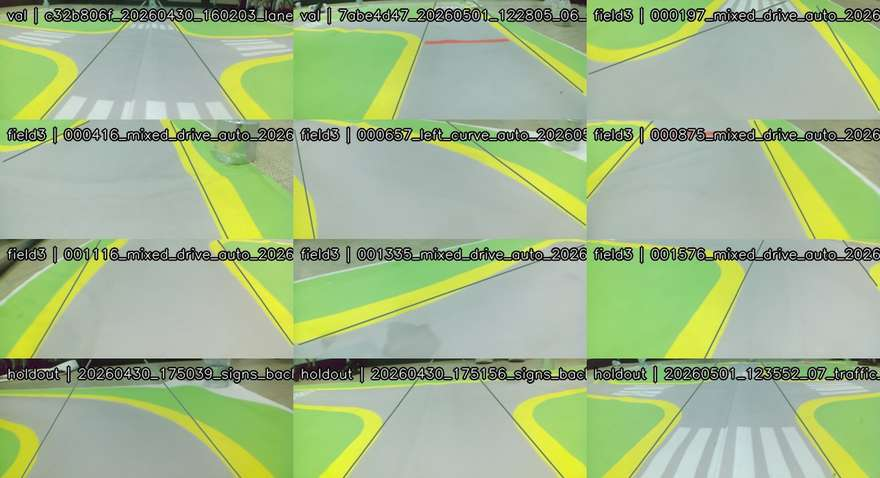

In [18]:
def draw_lanes_on_bgr(bgr, lanes, color, thickness=3):
    out = bgr.copy()
    for lane in lanes:
        pts = np.asarray(lane["points"], dtype=np.float32)
        pts = pts[np.isfinite(pts).all(axis=1)]
        if len(pts) < 2:
            continue
        poly = np.round(pts).astype(np.int32).reshape(-1, 1, 2)
        cv2.polylines(out, [poly], isClosed=False, color=color, thickness=thickness, lineType=cv2.LINE_AA)
    return out


def make_sheet(images, labels, out_path, max_cols=3, thumb_w=420):
    tiles = []
    for img, label in zip(images, labels):
        h, w = img.shape[:2]
        scale = thumb_w / float(w)
        tile = cv2.resize(img, (thumb_w, int(round(h * scale))), interpolation=cv2.INTER_AREA)
        cv2.putText(tile, label[:70], (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 0, 0), 4, cv2.LINE_AA)
        cv2.putText(tile, label[:70], (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 1, cv2.LINE_AA)
        tiles.append(tile)
    if not tiles:
        return None
    max_h = max(t.shape[0] for t in tiles)
    padded = []
    for t in tiles:
        if t.shape[0] < max_h:
            pad = np.zeros((max_h - t.shape[0], t.shape[1], 3), dtype=t.dtype)
            t = np.vstack([t, pad])
        padded.append(t)
    rows = []
    for i in range(0, len(padded), max_cols):
        row_tiles = padded[i:i + max_cols]
        while len(row_tiles) < max_cols:
            row_tiles.append(np.zeros_like(padded[0]))
        rows.append(np.hstack(row_tiles))
    sheet = np.vstack(rows)
    imwrite_bgr(out_path, sheet)
    return out_path


overlay_records = even_sample(all_records, OVERLAY_SAMPLE_FRAMES)
overlay_images = []
overlay_labels = []
for rec in overlay_records:
    key = f"{rec['set']}::{rec['id']}"
    bgr = imread_bgr(rec["image_path"])
    crop = bgr[int(cfg.cut_height):, :, :]
    # Display in raw crop coordinates. Lane y is raw full-image y, so subtract cut_height for crop display.
    def shift_lane(lane):
        pts = np.asarray(lane["points"], dtype=float).copy()
        pts[:, 1] -= int(cfg.cut_height)
        return {"points": pts.tolist(), "conf": lane.get("conf", np.nan)}
    shifted_pt = [shift_lane(l) for l in pt_lanes_by_key[key]]
    shifted_ox = [shift_lane(l) for l in onnx_lanes_by_key[key]]
    out = draw_lanes_on_bgr(crop, shifted_pt, (0, 255, 0), thickness=5)
    out = draw_lanes_on_bgr(out, shifted_ox, (255, 0, 255), thickness=2)
    overlay_images.append(out)
    overlay_labels.append(f"{rec['set']} | {rec['id']} | pt={len(shifted_pt)} onnx={len(shifted_ox)}")

overlay_path = OVERLAY_DIR / "pytorch_green_vs_onnx_magenta.jpg"
make_sheet(overlay_images, overlay_labels, overlay_path, max_cols=3, thumb_w=420)
print("saved:", overlay_path)
display(Image(filename=str(overlay_path)))


## Final parity report

아래 JSON은 10 Pi runtime 검증의 기준 문서다.  
Pi에서 같은 preprocess, 같은 ONNX, 같은 07 decoder, 같은 08 steering profile을 구현한 뒤 이 값들과 비교한다.


In [19]:
report = {
    "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "notebook": "09_onnx_export_parity_v1.ipynb",
    "status": "passed_local_onnx_parity",
    "onnx": {
        "path": str(ONNX_PATH),
        "opset_version": OPSET_VERSION,
        "input": {"name": "img", "shape": [1, 3, int(cfg.img_h), int(cfg.img_w)], "dtype": "float32"},
        "output": {"name": "predictions", "shape": [1, int(cfg.heads.num_priors), int(2 + 4 + cfg.num_points)], "dtype": "float32"},
        "size_mb": ONNX_PATH.stat().st_size / (1024 * 1024),
    },
    "preprocess_contract": {
        "color": "BGR",
        "crop": f"raw y >= cut_height ({int(cfg.cut_height)})",
        "resize": [int(cfg.img_w), int(cfg.img_h)],
        "range": "float32 [0, 1] by /255",
        "layout": "NCHW",
    },
    "decoder_contract": decode_contract["decoder_contract"],
    "driving_contract": {
        "name": drive_contract["driving_contract"]["name"],
        "params": drive_contract["driving_contract"]["params"],
    },
    "samples": {
        "val": len(val_records),
        "field3": len(field3_records),
        "holdout": len(holdout_records),
        "total": len(all_records),
    },
    "raw_parity": {
        "max_abs_diff": float(raw_df["max_abs_diff"].max()),
        "mean_abs_diff_max": float(raw_df["mean_abs_diff"].max()),
        "p99_abs_diff_max": float(raw_df["p99_abs_diff"].max()),
        "raw_max_abs_tol": RAW_MAX_ABS_TOL,
        "raw_mean_abs_tol": RAW_MEAN_ABS_TOL,
    },
    "decode_parity": {
        "count_mismatch": int((~decode_df["count_equal"]).sum()),
        "max_pair_dist_px": float(decode_df["max_pair_dist_px"].max()),
        "lane_mean_dist_tol_px": LANE_MEAN_DIST_TOL_PX,
    },
    "steering_parity": {
        "field3_frames": len(field3_records),
        "max_steer_abs_diff": float(drive_compare["steer_abs_diff"].max()),
        "max_center_abs_diff": float(drive_compare["center_abs_diff"].max()),
        "max_heading_abs_diff": float(drive_compare["heading_abs_diff"].max()),
        "mode_mismatch": int((~drive_compare["mode_equal"]).sum()),
        "steer_tol": STEER_TOL,
    },
    "artifacts": {
        "raw_parity_csv": str(raw_csv),
        "decode_parity_csv": str(decode_csv),
        "steering_parity_csv": str(drive_csv),
        "overlay": str(overlay_path),
        "report": str(PARITY_REPORT_PATH),
    },
    "next": [
        "10 Pi runtime에서 같은 preprocess + ONNX + 07 decoder + 08 steering profile을 구현한다.",
        "Pi에서 같은 sample image를 넣어 raw/decode/steer 결과를 이 report와 비교한다.",
        "이후 latency를 preprocess / inference / decode / steering으로 나눠 측정한다.",
    ],
}

write_text(PARITY_REPORT_PATH, json.dumps(report, ensure_ascii=False, indent=2))
print(json.dumps(report, ensure_ascii=False, indent=2))
print("saved report:", PARITY_REPORT_PATH)


{
  "created_at": "2026-05-10 09:35:49",
  "notebook": "09_onnx_export_parity_v1.ipynb",
  "status": "passed_local_onnx_parity",
  "onnx": {
    "path": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\10_experiments\\12_clrkdnet_supervised_rebuild\\review_outputs\\09_onnx_export_parity_v1\\models\\MapLane_LocalFit_Field12_v1_best_opset17_static_b1.onnx",
    "opset_version": 17,
    "input": {
      "name": "img",
      "shape": [
        1,
        3,
        320,
        800
      ],
      "dtype": "float32"
    },
    "output": {
      "name": "predictions",
      "shape": [
        1,
        192,
        78
      ],
      "dtype": "float32"
    },
    "size_mb": 0.35436153411865234
  },
  "preprocess_contract": {
    "color": "BGR",
    "crop": "raw y >= cut_height (445)",
    "resize": [
      800,
      320
    ],
    "range": "float32 [0, 1] by /255",
    "layout": "NCHW"
  },
  "decoder_contract": {
    "name": "official_overlap_python",
    "conf_thres

## 다음 단계

09가 통과하면 모델 배포 파일의 로컬 정합성은 확인된 것이다.

10에서는 Pi에서 같은 것을 확인한다.

1. Pi에 ONNX와 runtime 스크립트를 올린다.
2. Pi에서 preprocess가 09와 같은지 확인한다.
3. Pi ONNX raw output이 09의 ONNX Runtime 결과와 같은지 확인한다.
4. Pi decoder/steering 결과가 09와 같은지 확인한다.
5. latency를 나눠 잰다.
6. 실험실 맵에서 08 steering profile 값만 바꿔가며 주행한다.
